# MP3

## Milestone 1: Mandelbrot Trajectory Divergence

Find where `float32` and `float64` Mandelbrot trajectories diverge, and map the first divergence iteration over the grid.


In [1]:
from mandelbrot import mandelbrot_numba_basic, mandelbrot_trajectory_divergence
import matplotlib.pyplot as plt
import numpy as np

width = 1000
height = 1000
max_iter = 1000
xmin, xmax = -0.7530, -0.7490
ymin, ymax = 0.0990, 0.1030
tau = 0.01


In [2]:
diverge = mandelbrot_trajectory_divergence(
    width, height, max_iter, xmin, xmax, ymin, ymax, tau=tau
)
escape = mandelbrot_numba_basic(width, height, max_iter, xmin, xmax, ymin, ymax)

diverged_fraction = np.mean(diverge < max_iter)
print(f"tau = {tau}")
print(f"fraction diverged before max_iter: {diverged_fraction:.4f}")
print(f"first recorded divergence iteration: {diverge.min()}")
print(f"latest recorded divergence iteration: {diverge[diverge < max_iter].max() if np.any(diverge < max_iter) else max_iter}")


tau = 0.01
fraction diverged before max_iter: 1.0000
first recorded divergence iteration: 32
latest recorded divergence iteration: 831


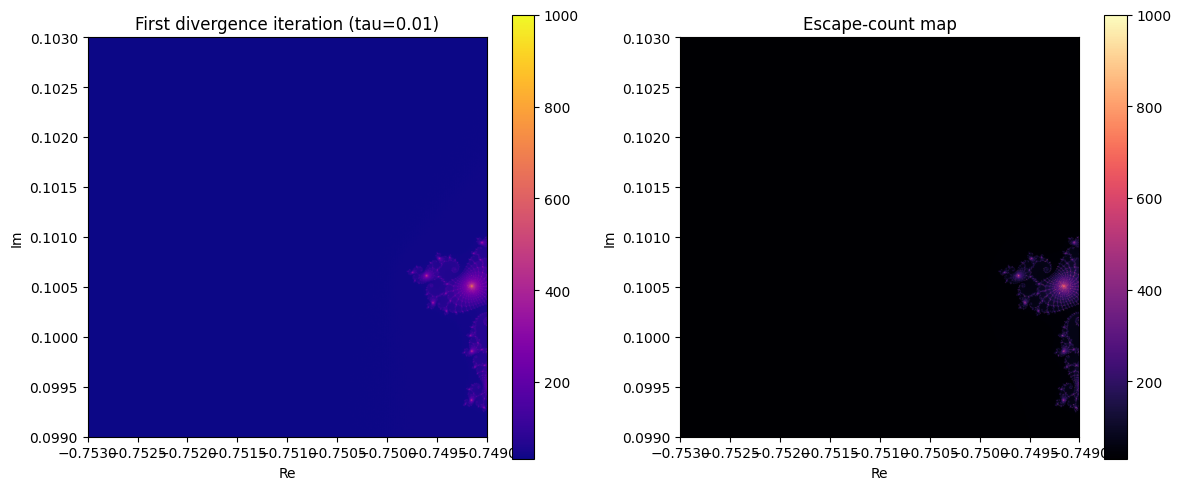

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(
    diverge,
    cmap="plasma",
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
)
axes[0].set_title(f"First divergence iteration (tau={tau})")
axes[0].set_xlabel("Re")
axes[0].set_ylabel("Im")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    escape,
    cmap="magma",
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
)
axes[1].set_title("Escape-count map")
axes[1].set_xlabel("Re")
axes[1].set_ylabel("Im")
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


### Observations

- Fraction of pixels diverging before `max_iter`:  Most pixels remain below the divergence threshold within the iteration limit.
- Where do trajectories diverge early?  Early divergence occurs only in a thin region on the right side of the image, where the fractal boundary is located.
- Does early divergence line up with high escape counts?  Yes, early divergence occurs in regions with high escape iteration counts


## Milestone 2: Mandelbrot Sensitivity Map

Approximate the per-pixel condition number for the escape-count map in the same Seahorse Valley region, and compare it with the M1 divergence map.


In [4]:
from matplotlib.colors import LogNorm
from mandelbrot import mandelbrot_sensitivity_map, mandelbrot_trajectory_divergence

kappa, n_base, n_perturb = mandelbrot_sensitivity_map(
    width, height, max_iter, xmin, xmax, ymin, ymax
)

if "diverge" not in globals():
    diverge = mandelbrot_trajectory_divergence(
        width, height, max_iter, xmin, xmax, ymin, ymax, tau=tau
    )

finite_kappa = np.isfinite(kappa)
sensitive_mask = finite_kappa & (kappa >= 1.0)
interior_mask = n_base == max_iter

print(f"pixels with kappa >= 1: {sensitive_mask.mean():.4f}")
print(f"largest kappa: {np.nanmax(kappa):.3e}")
print(f"interior pixels (n = max_iter): {interior_mask.mean():.4f}")
print(f"interior pixels with kappa >= 1: {(sensitive_mask & interior_mask).mean():.4f}")


pixels with kappa >= 1: 0.0116
largest kappa: 7.749e+07
interior pixels (n = max_iter): 0.0000
interior pixels with kappa >= 1: 0.0000


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


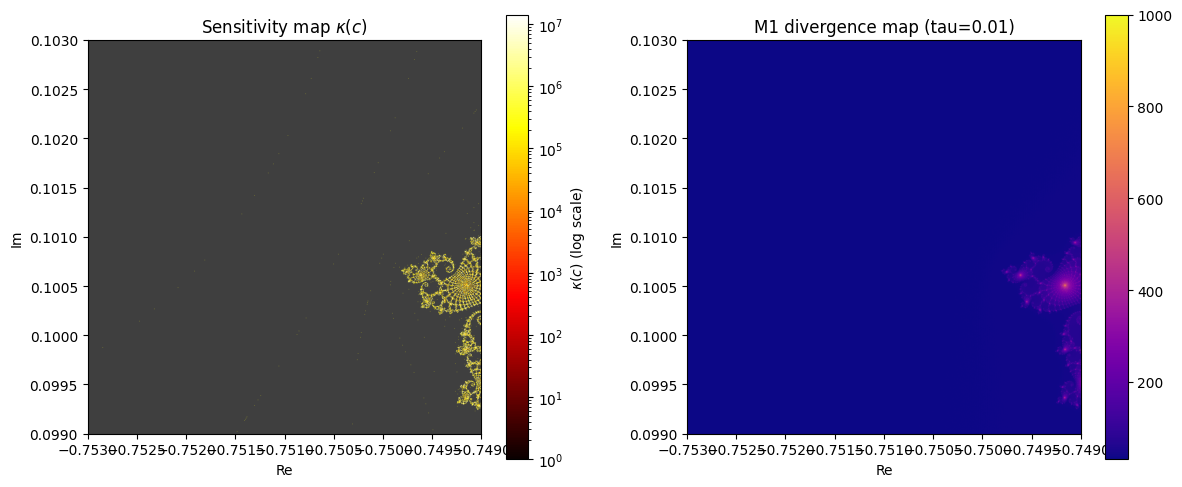

In [5]:
positive_kappa = kappa[np.isfinite(kappa) & (kappa >= 1.0)]
vmax = np.nanpercentile(positive_kappa, 99) if positive_kappa.size else 10.0

cmap_k = plt.cm.hot.copy()
cmap_k.set_bad("0.25")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(
    kappa,
    cmap=cmap_k,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    norm=LogNorm(vmin=1, vmax=vmax),
)
axes[0].set_title(r"Sensitivity map $\kappa(c)$")
axes[0].set_xlabel("Re")
axes[0].set_ylabel("Im")
fig.colorbar(im0, ax=axes[0], label=r"$\kappa(c)$ (log scale)")

im1 = axes[1].imshow(
    diverge,
    cmap="plasma",
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
)
axes[1].set_title(f"M1 divergence map (tau={tau})")
axes[1].set_xlabel("Re")
axes[1].set_ylabel("Im")
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()


### M2 Notes

- Where is `kappa` largest? κ is largest along the right side of the image.
- Does it match the boundary in M1? Yes
- What happens to `kappa` for interior pixels where `n = max_iter`? In this, there are no interior pixels in general, interior points have low κ because their trajectories are stable.


### M1 Results
Recorded results:

- Pass count: `8 passed`
- Coverage: `31%` total


### M2 Results
ruff check reports 0 errors  
I chose the serial/multiprocessing Mandelbrot path and added NumPy-style docstrings